# IMPORT LIBARARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,precision_recall_curve,average_precision_score,RocCurveDisplay,PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
import shap
import joblib
print("All Libararies Imported Scuccessfully")

All Libararies Imported Scuccessfully


# LOAD DATASET

In [2]:
df=pd.read_csv("creditcard.csv")
print(f"DATASET SHAPE :{df.shape}")
df.head()

DATASET SHAPE :(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# EDA 

In [3]:
print("Class distribution:\n")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")

Class distribution:

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


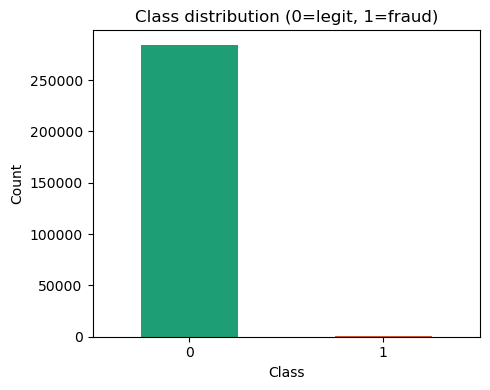

In [4]:
plt.figure(figsize=(5, 4))
df['Class'].value_counts().plot(kind='bar',
    color=['#1D9E75', '#D85A30'], edgecolor='none')
plt.title('Class distribution (0=legit, 1=fraud)')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

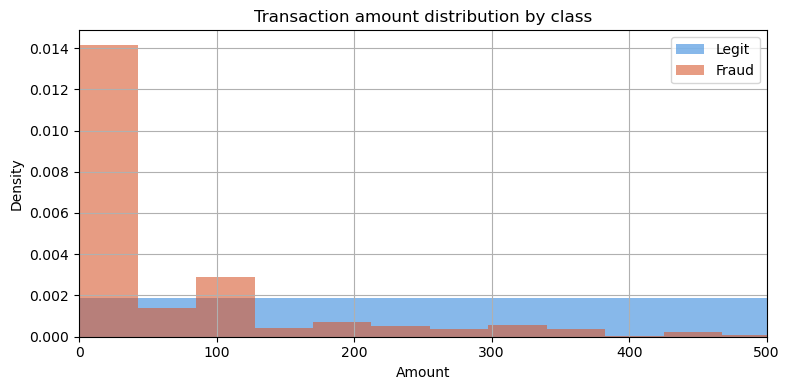

In [5]:
plt.figure(figsize=(8, 4))
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.6,
    color='#378ADD', label='Legit', density=True)
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.6,
    color='#D85A30', label='Fraud', density=True)
plt.title('Transaction amount distribution by class')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

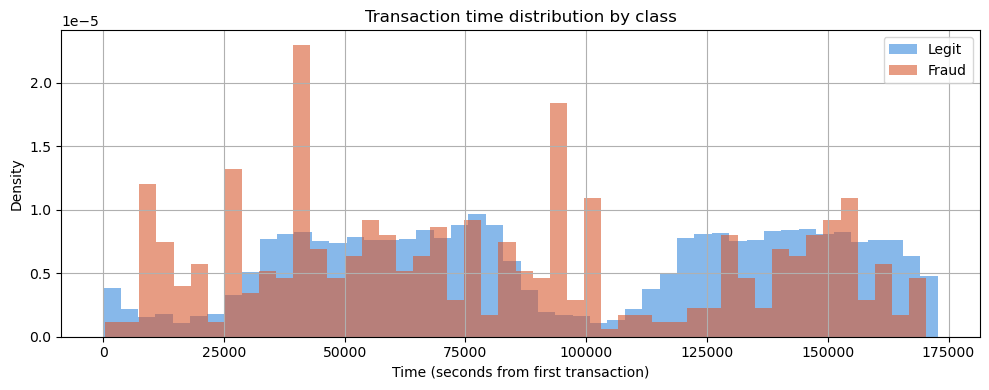

In [6]:
plt.figure(figsize=(10, 4))
df[df['Class'] == 0]['Time'].hist(bins=48, alpha=0.6,
    color='#378ADD', label='Legit', density=True)
df[df['Class'] == 1]['Time'].hist(bins=48, alpha=0.6,
    color='#D85A30', label='Fraud', density=True)
plt.title('Transaction time distribution by class')
plt.xlabel('Time (seconds from first transaction)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

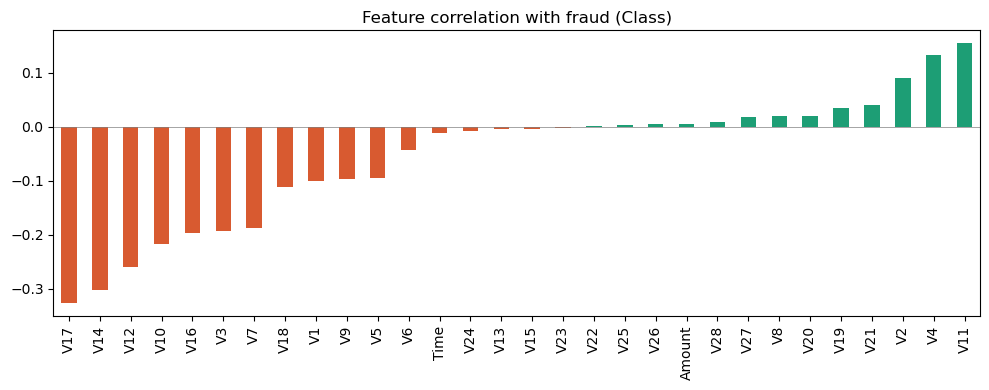

Top 5 positively correlated with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [7]:
correlations = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 4))
correlations.plot(kind='bar',
    color=['#D85A30' if x < 0 else '#1D9E75' for x in correlations],
    edgecolor='none')
plt.title('Feature correlation with fraud (Class)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 5 positively correlated with fraud:")
print(correlations.tail(5))
print("\nTop 5 negatively correlated with fraud:")
print(correlations.head(5))

# PREPROCESSING

In [8]:
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


In [9]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_scaled,Time_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964,-1.996583
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475,-1.996583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686,-1.996562
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534,-1.996562
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403,-1.996541


**BEFORE SMOTE**

In [16]:
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nFraud cases in test set: {y_test.sum()}")

Train size: (227845, 32)
Test size:  (56962, 32)

Fraud cases in test set: 98


**AFTER SMOTE**

In [15]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE — training set:")
print(f"  Class 0 (legit):  {(y_train_sm == 0).sum()}")
print(f"  Class 1 (fraud):  {(y_train_sm == 1).sum()}")
print(f"  Total rows: {len(X_train_sm)}")

After SMOTE — training set:
  Class 0 (legit):  227451
  Class 1 (fraud):  227451
  Total rows: 454902


# TRAINING MODEL

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}
results = {}
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    results[name] = {'ROC-AUC': auc, 'PR-AUC': pr_auc}
    trained_models[name] = model
    print(f"  ROC-AUC: {auc:.4f}  |  PR-AUC: {pr_auc:.4f}\n")
print("Best by PR-AUC:", max(results, key=lambda k: results[k]['PR-AUC']))

Training Logistic Regression...
  ROC-AUC: 0.9760  |  PR-AUC: 0.7356

Training Random Forest...
  ROC-AUC: 0.9740  |  PR-AUC: 0.8686

Training XGBoost...
  ROC-AUC: 0.9831  |  PR-AUC: 0.8671

Best by PR-AUC: Random Forest


# EVALUATE

In [20]:
best_name = max(results, key=lambda k: results[k]['PR-AUC'])
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)
print(f"=== {best_name} ===")
print(classification_report(y_test, y_pred,target_names=['Legit', 'Fraud']))

=== Random Forest ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



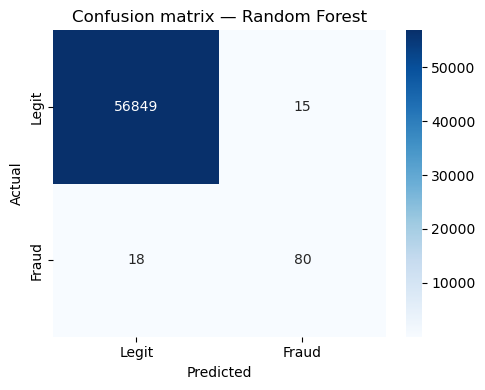

In [21]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Blues',xticklabels=['Legit', 'Fraud'],yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

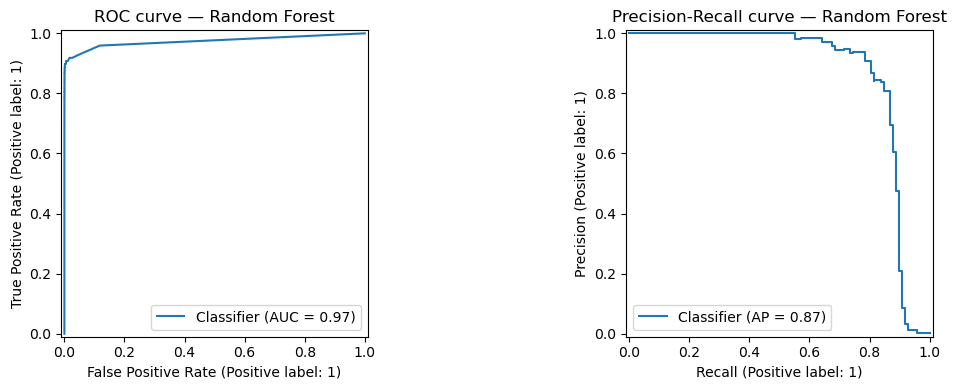

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'ROC curve — {best_name}')
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f'Precision-Recall curve — {best_name}')
plt.tight_layout()
plt.show()

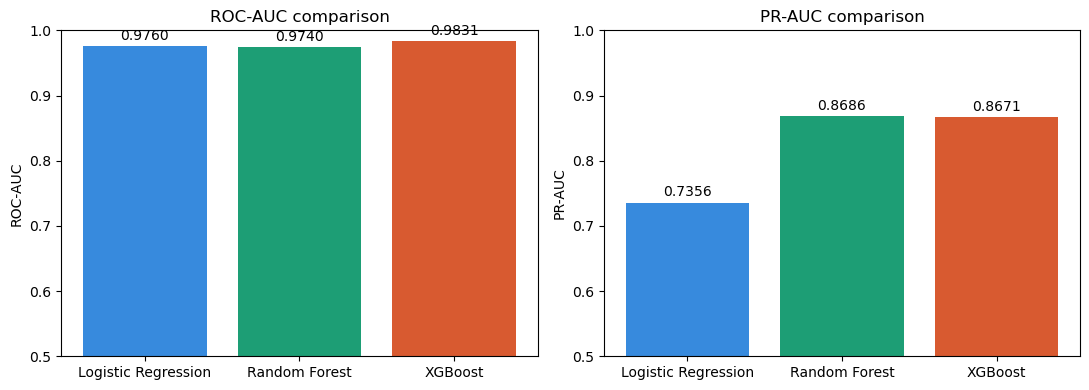

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(results.keys())
colors = ['#378ADD', '#1D9E75', '#D85A30']
for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.005,f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f'{metric} comparison')
    ax.set_ylabel(metric)
plt.tight_layout()
plt.show()

# SHAP AND SAVING MODEL

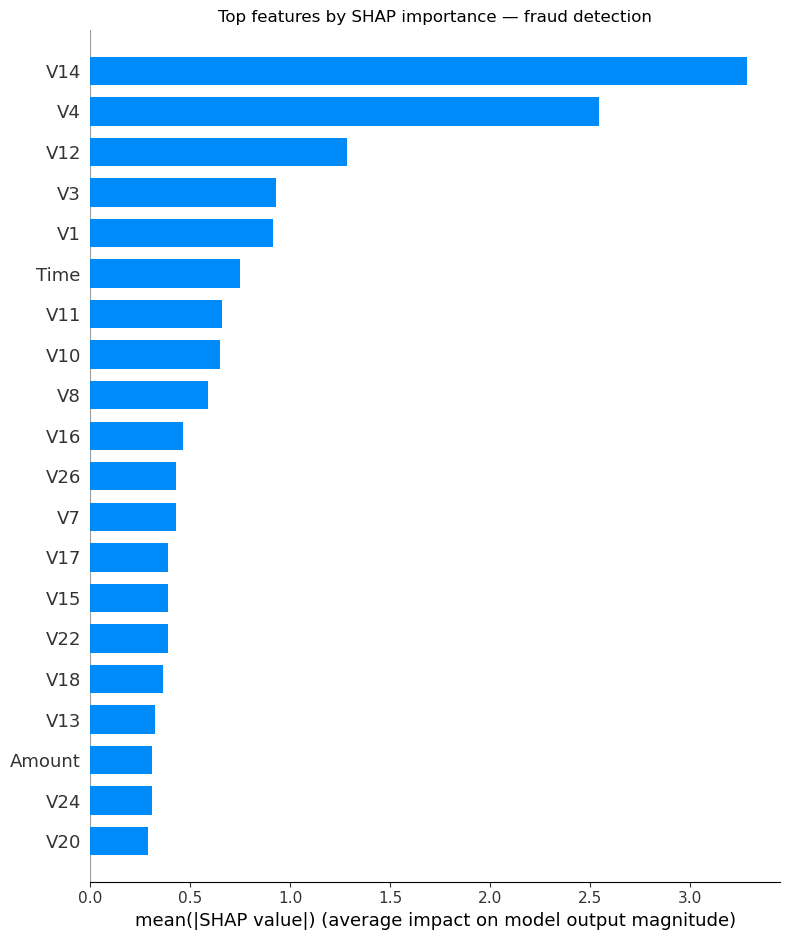

In [24]:
xgb_model = trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Top features by SHAP importance — fraud detection')
plt.tight_layout()
plt.savefig('shap_fraud_summary.png', dpi=150, bbox_inches='tight')
plt.show()

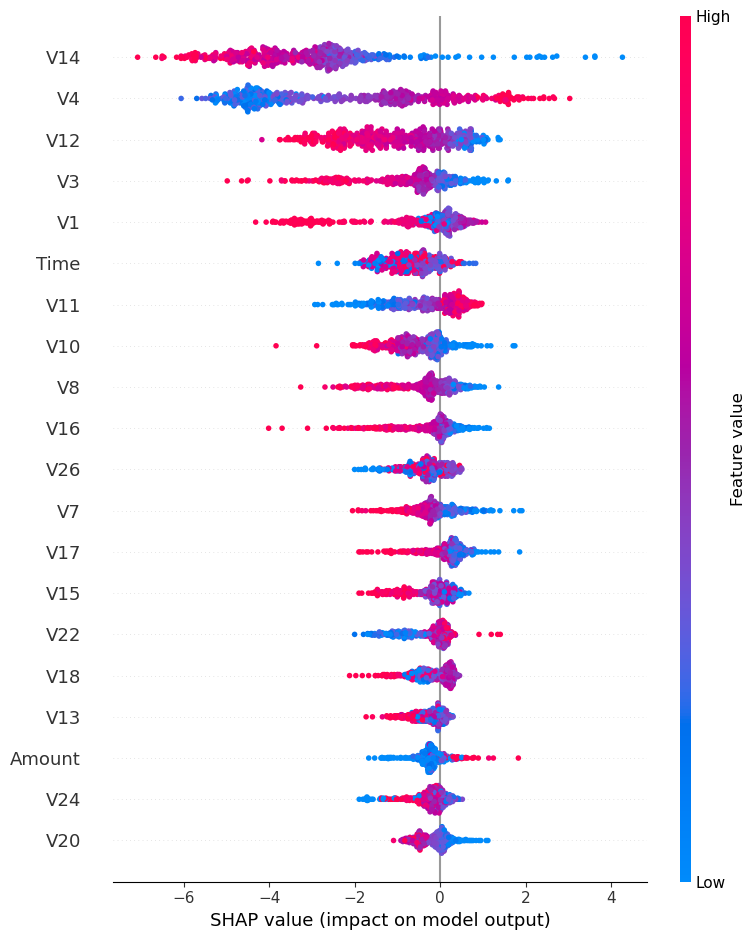

In [25]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

In [26]:
joblib.dump(xgb_model, 'fraud_detection_model.pkl')
print("Model saved as fraud_detection_model.pkl")
print(f"\nNotebook 2 complete!")
print(f"Best model: {best_name}")
print(f"ROC-AUC: {results[best_name]['ROC-AUC']:.4f}")
print(f"PR-AUC:  {results[best_name]['PR-AUC']:.4f}")

Model saved as fraud_detection_model.pkl

Notebook 2 complete!
Best model: Random Forest
ROC-AUC: 0.9740
PR-AUC:  0.8686
